# Effect Handlers in NumPyro: A Practical Guide

NumPyro's **effect handler** system is the backbone of its inference engine. Every time your model calls `numpyro.sample(...)`, the call passes through a stack of handlers that can intercept, modify, or record the operation, without changing the model code itself. This composability is what makes NumPyro (and Pyro) uniquely powerful among probabilistic programming languages.

In this tutorial we will:

1. Understand what effect handlers are and how they work.
2. Walk through each of NumPyro's built-in handlers with concrete examples.
3. Learn how to compose handlers for practical tasks like posterior prediction,
   causal inference, and reparameterization.

**Prerequisites:** Basic familiarity with NumPyro models (e.g. `numpyro.sample`, `numpyro.plate`, MCMC). No prior knowledge of effect handlers is assumed.

**Tutorial Outline:**

1. [What Are Effect Handlers?](#what-are-effect-handlers)
2. [The Running Model](#the-running-model)
3. [Inspection: `seed` and `trace`](#inspection-seed-and-trace)
4. [Conditioning: `condition` vs `substitute`](#conditioning-condition-vs-substitute)
5. [Model Surgery: `block`, `uncondition`, `lift`](#model-surgery-block-uncondition-lift)
6. [Composition: `scope` and `replay`](#composition-scope-and-replay)
7. [Scaling and Masking: `scale` and `mask`](#scaling-and-masking-scale-and-mask)
8. [Causal Inference: `do`](#causal-inference-do)
9. [Reparameterization: `reparam`](#reparameterization-reparam)
10. [Composing Handlers: Nesting and Order](#composing-handlers-nesting-and-order)
11. [Practical Recipe: Posterior Predictive with Handlers](#practical-recipe-posterior-predictive-with-handlers)
12. [Summary and References](#summary-and-references)

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp

import numpyro
from numpyro import handlers
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.reparam import LocScaleReparam

numpyro.set_host_device_count(4)

plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

rng_key = jax.random.key(42)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

## What Are Effect Handlers?
<a id="what-are-effect-handlers"></a>

In NumPyro, a probabilistic model is just a Python function that calls primitives like `numpyro.sample("x", dist.Normal(0, 1))`. Normally, this would just draw a random sample. But what if we want to:

- **Record** every sample site for debugging? → use `trace`
- **Fix** a variable to an observed value? → use `condition`
- **Intervene** on a variable for causal inference? → use `do`
- **Block** certain variables from being seen by inference? → use `block`

Effect handlers let us do all of this **without modifying the model function**. They work by intercepting the messages that primitives send through a global handler stack.

### The Messenger Pattern

The conceptual foundation comes from Pyro's [Mini Pyro tutorial](https://pyro.ai/examples/minipyro.html), which is an excellent resource for understanding the design from scratch. Here is the key idea:

1. Every handler is a `Messenger` subclass that gets pushed onto a global stack
   (`_PYRO_STACK`) when used as a context manager.
2. When a primitive like `sample()` is called, it creates a **message dictionary**
   and passes it through `apply_stack()`.
3. `apply_stack` has three phases:
   - **Phase 1 — `process_message`** (bottom → top of stack): each handler can
     inspect and modify the message.
   - **Phase 2 — default execution**: if no handler set `msg["value"]`, the
     distribution is sampled.
   - **Phase 3 — `postprocess_message`** (top → bottom): handlers can record or
     further modify the final result.

### Message Anatomy

A sample-site message is a dictionary with fields like:

```python
{
    "type": "sample",         # primitive type
    "name": "slope",          # site name
    "fn": Normal(0, 5),       # distribution
    "value": None,            # sampled/observed value (filled by handler or default)
    "is_observed": False,     # True if this is observed data
    "scale": None,            # log-prob scaling factor
    "cond_indep_stack": [],   # enclosing plates
    "infer": {},              # metadata for inference algorithms
}
```

Each handler reads and writes specific fields in this dictionary. Understanding which fields each handler touches is the key to mastering their composition.

### Two Usage Modes

Every handler can be used as a **context manager** or as a **function wrapper**:

```python
# Context manager
with handlers.condition(data={"x": 1.0}):
    model()

# Function wrapper (equivalent)
handlers.condition(model, data={"x": 1.0})()
```

Throughout this tutorial we will use both styles depending on which is clearer.

## The Running Model
<a id="the-running-model"></a>

We will use a simple Bayesian linear regression model throughout this tutorial. This gives us a concrete, familiar context for exploring each handler.

First, we generate and visualize some synthetic data:

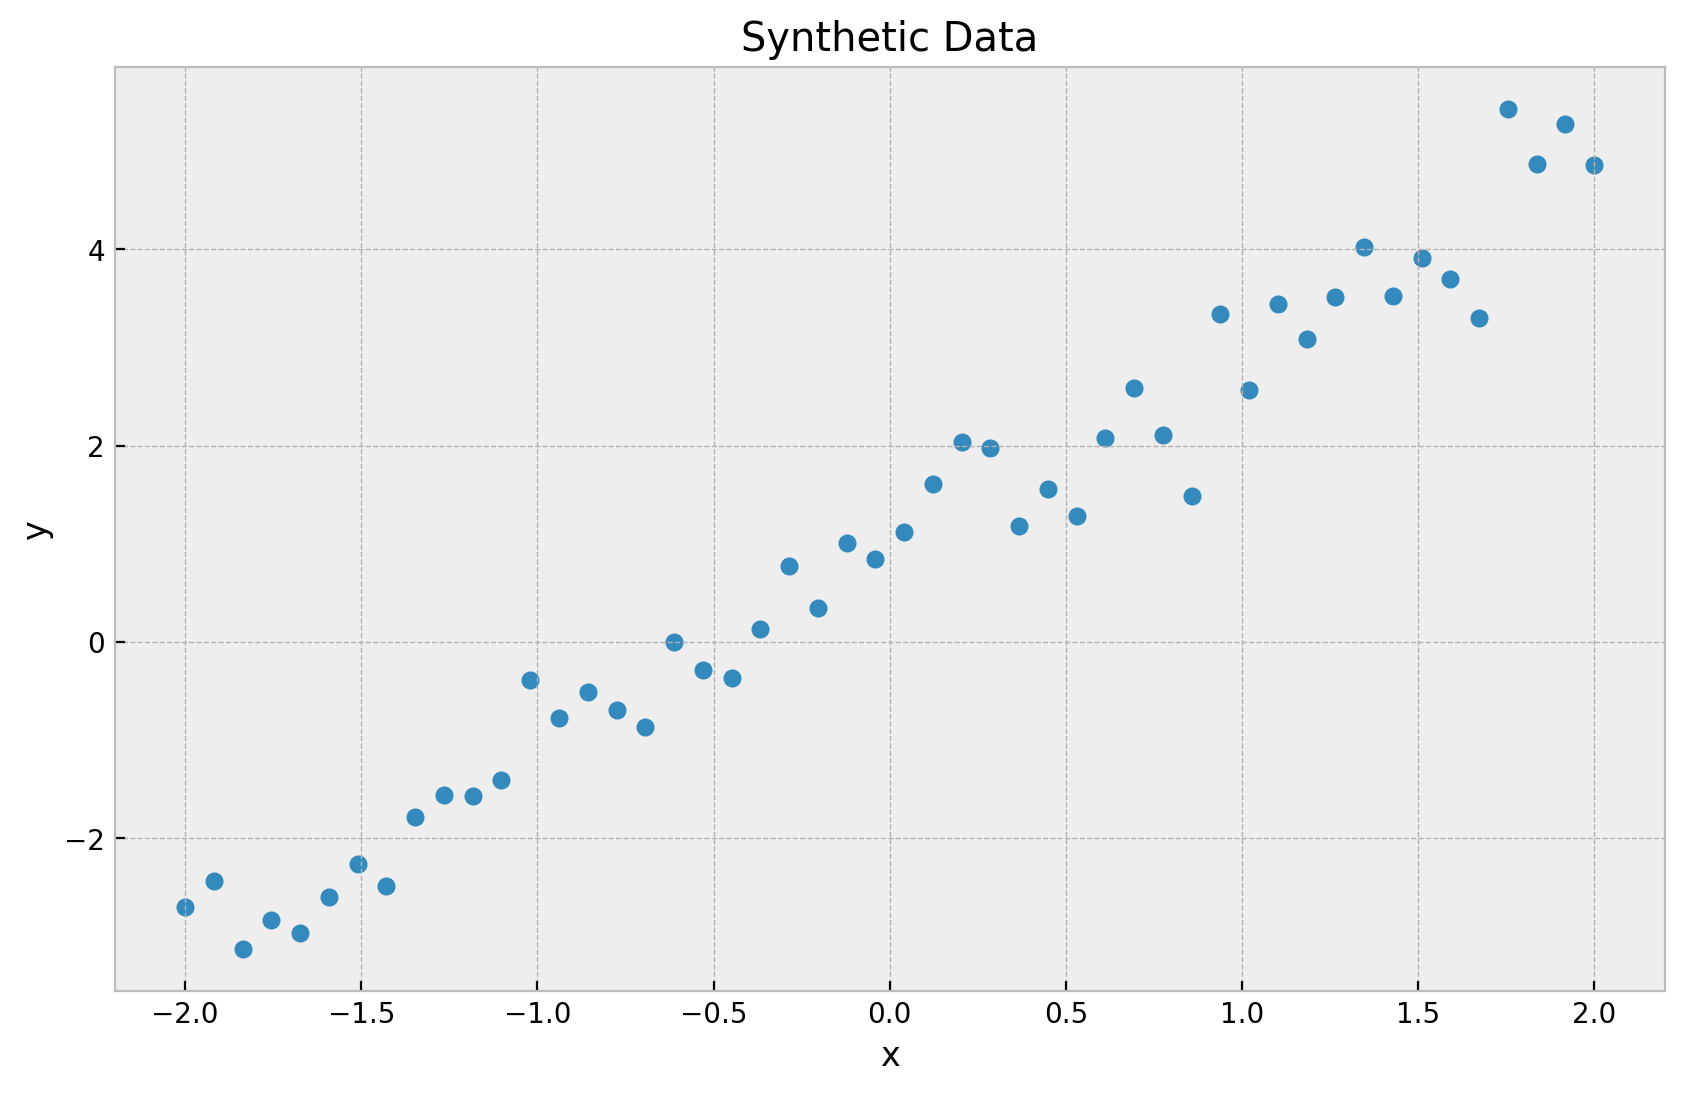

In [2]:
n_obs = 50
rng_key, rng_subkey = jax.random.split(rng_key)
true_intercept, true_slope, true_sigma = 1.0, 2.0, 0.5
x_data = jnp.linspace(-2, 2, n_obs)
y_data = (
    true_intercept
    + true_slope * x_data
    + true_sigma * jax.random.normal(rng_subkey, shape=(n_obs,))
)

fig, ax = plt.subplots()
ax.scatter(x_data, y_data)
ax.set(
    title="Synthetic Data",
    xlabel="x",
    ylabel="y",
);

Now we define the linear model:

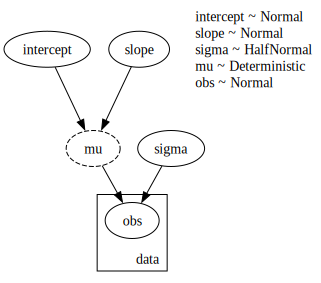

In [3]:
def linear_model(x):
    intercept = numpyro.sample("intercept", dist.Normal(0.0, 10.0))
    slope = numpyro.sample("slope", dist.Normal(0.0, 5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = numpyro.deterministic("mu", intercept + slope * x)
    with numpyro.plate("data", len(x)):
        numpyro.sample("obs", dist.Normal(mu, sigma))


# Visualize the model structure
numpyro.render_model(linear_model, model_args=(x_data,), render_distributions=True)

## Inspection: `seed` and `trace`
<a id="inspection-seed-and-trace"></a>

These two handlers are the foundation for everything else. `seed` provides the random number generation keys that JAX requires, and `trace` records the execution of every primitive site.

### `seed`: Providing Randomness

JAX has no global random state. Every random operation needs an explicit PRNG key. The `seed` handler automatically splits keys for each `sample` site so you don't have to thread keys manually.

In [4]:
# Using seed as a context manager
with handlers.seed(rng_seed=0):
    val = numpyro.sample("x", dist.Normal(0.0, 1.0))

print(f"Sampled value: {val:.4f}")

Sampled value: -2.4425


In [5]:
# Using seed as a function wrapper (equivalent)
val2 = handlers.seed(lambda: numpyro.sample("x", dist.Normal(0.0, 1.0)), rng_seed=0)()
print(f"Sampled value (wrapper): {val2:.4f}")
assert jnp.allclose(val, val2)

Sampled value (wrapper): -2.4425


### `trace`:  Recording Execution

The `trace` handler records every message into an `OrderedDict` keyed by site name. This is the primary introspection tool for understanding what a model does.

In [6]:
# Trace the model and inspect the result
exec_trace = handlers.trace(handlers.seed(linear_model, rng_seed=0)).get_trace(x_data)

print(f"{'Site':>12s} | {'Type':>15s} | {'is_observed':>12s} | {'Value shape'}")
print("-" * 70)
for name, site in exec_trace.items():
    print(
        f"{name:>12s} | {site['type']:>15s} | "
        f"{str(site.get('is_observed', 'N/A')):>12s} | "
        f"{jnp.shape(site['value'])}"
    )

        Site |            Type |  is_observed | Value shape
----------------------------------------------------------------------
   intercept |          sample |        False | ()
       slope |          sample |        False | ()
       sigma |          sample |        False | ()
          mu |   deterministic |          N/A | (50,)
        data |           plate |          N/A | (50,)
         obs |          sample |        False | (50,)


Let's deep-dive into the message dictionary for the `slope` site to see all the fields a handler can read or modify:

In [7]:
slope_site = exec_trace["slope"]
# Show key fields (excluding internal JAX arrays for readability)
slope_site

{'type': 'sample',
 'name': 'slope',
 'fn': <numpyro.distributions.continuous.Normal object at 0x13f0e2030 with batch shape () and event shape ()>,
 'args': (),
 'kwargs': {'rng_key': Array((), dtype=key<fry>) overlaying:
  [1353695780 2116000888],
  'sample_shape': ()},
 'value': Array(-6.2873883, dtype=float32),
 'scale': None,
 'is_observed': False,
 'intermediates': [],
 'cond_indep_stack': [],
 'infer': {}}

## Conditioning: `condition` vs `substitute`
<a id="conditioning-condition-vs-substitute"></a>

These two handlers both set the value of a site, but they differ in a critical way:

| Handler | Sets `value`? | Sets `is_observed`? | Use case |
|---------|:---:|:---:|---|
| `condition` | Yes | **Yes** (→ `True`) | Observed data, clamping for inference |
| `substitute` | Yes | No (stays `False`) | Plugging in posterior samples, testing |

The `is_observed` flag matters because it affects how inference algorithms treat the site: observed sites contribute to the likelihood but are not sampled.

In [8]:
# condition: sets value AND marks as observed
conditioned_trace = handlers.trace(
    handlers.seed(handlers.condition(linear_model, data={"slope": 3.0}), rng_seed=0)
).get_trace(x_data)

print("condition:")
print(f"  slope value:       {conditioned_trace['slope']['value']}")
print(f"  slope is_observed: {conditioned_trace['slope']['is_observed']}")

condition:
  slope value:       3.0
  slope is_observed: True


In [9]:
# substitute: sets value but does NOT mark as observed
substituted_trace = handlers.trace(
    handlers.seed(handlers.substitute(linear_model, data={"slope": 3.0}), rng_seed=0)
).get_trace(x_data)

print("substitute:")
print(f"  slope value:       {substituted_trace['slope']['value']}")
print(f"  slope is_observed: {substituted_trace['slope']['is_observed']}")

substitute:
  slope value:       3.0
  slope is_observed: False


**When to use which:**

- Use `condition` when you want to **observe** a variable, i.e., fix it to a known value and have it contribute to the log-likelihood (e.g., conditioning on data).
- Use `substitute` when you want to **plug in** a value without changing the observation status (e.g., substituting posterior samples for prediction).

## Model Surgery: `block`, `uncondition`, `lift`
<a id="model-surgery-block-uncondition-lift"></a>

These handlers let you modify which sites are visible, which are observed, and whether parameters become random variables.

### `block`: Hiding Sites

The `block` handler hides sites from outer handlers by setting `msg["stop"] = True`. Hidden sites still execute, but they won't appear in an outer `trace`.

In [10]:
# Hide the "sigma" site
blocked_trace = handlers.trace(
    handlers.seed(handlers.block(linear_model, hide=["sigma"]), rng_seed=0)
).get_trace(x_data)

print("Sites in blocked trace:", list(blocked_trace.keys()))
assert "sigma" not in blocked_trace

Sites in blocked trace: ['intercept', 'slope', 'mu', 'data', 'obs']


In [11]:
# Inverse: expose only specific sites (hide everything else)
exposed_trace = handlers.trace(
    handlers.seed(
        handlers.block(linear_model, expose=["slope", "intercept"]), rng_seed=0
    )
).get_trace(x_data)

print("Sites in exposed trace:", list(exposed_trace.keys()))

Sites in exposed trace: ['intercept', 'slope']


In [12]:
# Custom logic with hide_fn

hidden_samples_trace = handlers.trace(
    handlers.seed(
        handlers.block(
            linear_model,
            hide_fn=lambda site: site["type"] == "sample" and not site["is_observed"],
        ),
        rng_seed=0,
    )
).get_trace(x_data)

print("Sites (hiding unobserved samples):", list(hidden_samples_trace.keys()))

Sites (hiding unobserved samples): ['mu', 'data']


### `uncondition`: Forgetting Observations

The `uncondition` handler forces observed sites to sample from their prior distribution instead of using the observed value. This is useful for prior predictive checking when your model has hard-coded observations.

In [13]:
# Condition the model on the observed data.
conditioned_linear_model = handlers.condition(linear_model, data={"obs": y_data})

# Normal execution: obs is observed
obs_trace = handlers.trace(
    handlers.seed(conditioned_linear_model, rng_seed=0)
).get_trace(x_data)
print(f"obs is_observed: {obs_trace['obs']['is_observed']}")
print(f"obs value[:3]:   {obs_trace['obs']['value'][:3]}")
print(f"y_data[:3]:      {y_data[:3]}")

obs is_observed: True
obs value[:3]:   [-2.697118  -2.4372127 -3.127933 ]
y_data[:3]:      [-2.697118  -2.4372127 -3.127933 ]


In [14]:
# Unconditioned: samples from prior even though y was passed

uncond_trace = handlers.trace(
    handlers.uncondition(handlers.seed(conditioned_linear_model, rng_seed=0))
).get_trace(x_data)

print(f"obs is_observed:  {uncond_trace['obs']['is_observed']}")
print(f"obs was_observed: {uncond_trace['obs']['infer']['was_observed']}")
print(f"obs value[:3]:    {uncond_trace['obs']['value'][:3]}  (sampled, not y_data!)")

obs is_observed:  False
obs was_observed: True
obs value[:3]:    [-15.044792 -12.289793 -10.538498]  (sampled, not y_data!)


### `lift`: Parameters to Random Variables

The `lift` handler converts `numpyro.param` sites into `numpyro.sample` sites by providing a prior distribution. This bridges the gap between optimization-based inference (SVI with params) and full Bayesian inference (MCMC with samples).

In [15]:
def model_with_param(x):
    """A model using numpyro.param (typically for SVI/optimization)."""
    s = numpyro.param("s", 1.0, constraint=dist.constraints.positive)
    loc = numpyro.sample("loc", dist.Normal(0.0, s))
    numpyro.sample("obs", dist.Normal(loc, 1.0), obs=x)


# Without lift: 's' is a param
param_trace = handlers.trace(handlers.seed(model_with_param, rng_seed=0)).get_trace(
    jnp.ones(5)
)
print(f"Without lift: 's' type = {param_trace['s']['type']}")

# With lift: 's' becomes a sample from Exponential(1)
lifted_model = handlers.lift(model_with_param, prior={"s": dist.Exponential(1.0)})
lifted_trace = handlers.trace(handlers.seed(lifted_model, rng_seed=0)).get_trace(
    jnp.ones(5)
)
print(f"With lift:    's' type = {lifted_trace['s']['type']}")
print(f"              's' value = {lifted_trace['s']['value']:.4f}")

Without lift: 's' type = param
With lift:    's' type = sample
              's' value = 0.0073


## Composition: `scope` and `replay`
<a id="composition-scope-and-replay"></a>

These handlers support modular model building and deterministic replay of execution traces.

### `scope`: Namespacing Sites

The `scope` handler prepends a prefix to all site names, enabling you to reuse the same model component multiple times without name collisions.

In [16]:
def component():
    z = numpyro.sample("z", dist.Normal(0.0, 1.0))
    return z


def composed_model():
    with handlers.scope(prefix="first", divider="::"):
        z1 = component()
    with handlers.scope(prefix="second", divider="/"):
        z2 = component()
    numpyro.deterministic("diff", z1 - z2)


trace_composed = handlers.trace(handlers.seed(composed_model, rng_seed=0)).get_trace()
print("Sites:", list(trace_composed.keys()))

Sites: ['first::z', 'second/z', 'diff']


The `divider` parameter controls the separator (default is `"/"`):

```python
with handlers.scope(prefix="group", divider="."):
    ...  # sites become "group.x", "group.y", etc.
```

### `replay`: Deterministic Replay

The `replay` handler substitutes sample values from a previously recorded trace. Unlike `substitute` (which takes a simple dict), `replay` takes a full trace dict with metadata.  

In [17]:
# Record a trace
original_trace = handlers.trace(handlers.seed(linear_model, rng_seed=0)).get_trace(
    x_data
)
print(f"Original slope: {original_trace['slope']['value']:.4f}")

# Replay with a DIFFERENT seed — replay overrides the sampled values
replayed_trace = handlers.trace(
    handlers.replay(handlers.seed(linear_model, rng_seed=99), trace=original_trace)
).get_trace(x_data)
print(f"Replayed slope: {replayed_trace['slope']['value']:.4f}")

assert jnp.allclose(original_trace["slope"]["value"], replayed_trace["slope"]["value"])
print("Values match despite different seed!")

Original slope: -6.2874
Replayed slope: -6.2874
Values match despite different seed!


## Scaling and Masking: `scale` and `mask`
<a id="scaling-and-masking-scale-and-mask"></a>

These handlers modify the log-probability contribution of sample sites.

### `scale`: Rescaling Log-Probabilities

The `scale` handler multiplies `msg["scale"]` by a positive factor. This is used internally for data subsampling (upweighting a mini-batch to represent the full dataset).

In [18]:
def simple_obs_model():
    z = numpyro.sample("z", dist.Normal(0.0, 1.0))
    numpyro.sample("obs", dist.Normal(z, 1.0), obs=0.5)


# Without scale
normal_trace = handlers.trace(handlers.seed(simple_obs_model, rng_seed=0)).get_trace()
print(f"obs scale (no handler):   {normal_trace['obs']['scale']}")

# With scale=10.0
with handlers.trace() as scaled_trace:
    with handlers.scale(scale=10.0):
        handlers.seed(simple_obs_model, rng_seed=0)()
print(f"obs scale (with handler): {scaled_trace['obs']['scale']}")

obs scale (no handler):   None
obs scale (with handler): 10.0


### `mask`: Element-wise Masking

The `mask` handler applies a boolean mask to the log-probability computation. Elements where the mask is `False` are excluded from the likelihood. This is useful for handling missing data or implementing train/test splits within a model.

In [19]:
def model_for_mask():
    z = numpyro.sample("z", dist.Normal(0.0, 1.0))
    numpyro.sample("obs", dist.Normal(z, 1.0), obs=jnp.array([1.0, 2.0, 3.0]))


# Mask out the second observation
mask_array = jnp.array([True, False, True])
masked_trace = handlers.trace(
    handlers.seed(handlers.mask(model_for_mask, mask=mask_array), rng_seed=0)
).get_trace()

print(f"obs fn type: {type(masked_trace['obs']['fn']).__name__}")
print("(The distribution is now wrapped in a MaskedDistribution)")

obs fn type: MaskedDistribution
(The distribution is now wrapped in a MaskedDistribution)


You can also query the current mask inside your model using `numpyro.get_mask()`. This is useful for conditionally skipping expensive computations:

```python
def model():
    if numpyro.get_mask() is not False:
        numpyro.factor("expensive_term", expensive_computation())
```

## Causal Inference: `do`
<a id="causal-inference-do"></a>

The `do` handler implements Pearl's do-calculus intervention, following the Single World Intervention Graph (SWIG) framework by Richardson & Robins. This is one of NumPyro's most unique features, few other PPLs offer first-class support for causal interventions (PyMC does offers `pm.do`).

### How `do` Works

When you call `handlers.do(model, data={"z": val})`, the handler:

1. Creates a **fresh sample** at the original site name `"z"` (sampled freely from the prior, this represents the counterfactual "what would have happened"). This fresh sample appears in the trace.
2. Internally renames the original message to `"z__CF"` and sets it to the intervention value, but this is hidden from outer handlers (`stop=True`).
3. The **intervened value** `val` is what downstream code actually uses.

The net effect: the model *behaves* as if `z` was hard-coded to `val`, while the trace still records a free sample at `"z"` for bookkeeping.

Let's see this with a simple causal chain:

In [20]:
def causal_chain(x):
    """x → z → y"""
    z = numpyro.sample("z", dist.Normal(x, 1.0))
    y = numpyro.sample("y", dist.Normal(z, 0.5))
    return y


# Natural (observational) execution
natural_trace = handlers.trace(handlers.seed(causal_chain, rng_seed=0)).get_trace(1.0)
print(
    f"Natural: z = {natural_trace['z']['value']:.3f}, "
    f"y = {natural_trace['y']['value']:.3f}"
)

Natural: z = -1.442, y = -2.071


In [21]:
# Intervene: do(z = 5.0)
intervened_model = handlers.do(causal_chain, data={"z": 5.0})
with handlers.trace() as int_trace:
    y_result = handlers.seed(intervened_model, rng_seed=0)(1.0)

print("After do(z=5.0):")
print(f"  Trace sites: {list(int_trace.keys())}")
print(
    f"  'z' in trace (fresh sample, unused downstream): "
    f"value={int_trace['z']['value']:.3f}, "
    f"is_observed={int_trace['z']['is_observed']}"
)
print(f"  Returned y: {y_result:.3f} (downstream used the intervened z=5.0)")
# The key insight: z in the trace is NOT the intervention value,
# but downstream code (y) used the intervention z=5.0
assert int_trace["z"]["value"] != 5.0, (
    "z in trace is the free sample, not the intervention"
)

After do(z=5.0):
  Trace sites: ['z', 'y']
  'z' in trace (fresh sample, unused downstream): value=-1.442, is_observed=False
  Returned y: 4.371 (downstream used the intervened z=5.0)


### Applied Example: Collections Email Campaign

We now apply the `do` handler to a real-world causal inference problem from [Causal Inference for the Brave and True, Ch.7](https://matheusfacure.github.io/python-causality-handbook/07-Beyond-Confounders.html#good-controls) (see also [this NumPyro causal inference notebook](https://github.com/juanitorduz/website_projects/blob/master/Python/intro_causal_inference_ppl_numpyro.ipynb)).

A fintech company ran a **randomized experiment** sending debt negotiation emails to customers with late payments. The question: does the email cause customers to pay more?

**Variables:**
- `email` (treatment): whether the customer received the email
- `payments` (outcome): amount paid
- `credit_limit`, `risk_score` (good controls): pre-treatment predictors of
  payments that reduce residual variance

Since `email` was randomly assigned, there is no confounding. However, including `credit_limit` and `risk_score` as **good controls** improves statistical power by explaining outcome variance.

In [22]:
# Load data
data_url = (
    "https://raw.githubusercontent.com/matheusfacure/"
    "python-causality-handbook/master/causal-inference-for-the-brave-and-true"
    "/data/collections_email.csv"
)
df = pd.read_csv(data_url)

df.head()

,payments,email,opened,agreement,credit_limit,risk_score
0,740,1,1.0,0.0,2348.495260,0.666752
1,580,1,1.0,1.0,334.111969,0.207395
2,600,1,1.0,1.0,1360.660722,0.550479
3,770,0,0.0,0.0,1531.828576,0.560488
4,660,0,0.0,0.0,979.855647,0.455140


In [23]:
# Data statistics
df.describe()

,payments,email,opened,agreement,credit_limit,risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,669.672000,0.490800,0.273400,0.160800,1194.845188,0.480812
std,103.970065,0.499965,0.445749,0.367383,480.978996,0.100376
min,330.000000,0.000000,0.000000,0.000000,193.695573,0.131784
25%,600.000000,0.000000,0.000000,0.000000,843.049867,0.414027
50%,670.000000,0.000000,0.000000,0.000000,1127.640297,0.486389
75%,730.000000,1.000000,1.000000,0.000000,1469.096523,0.552727
max,1140.000000,1.000000,1.000000,1.000000,3882.178408,0.773459


In [24]:
# Prepare data for the model
email = jnp.array(df["email"].values, dtype=jnp.float32)
payments = jnp.array(df["payments"].values, dtype=jnp.float32)
credit_limit = jnp.array(df["credit_limit"].values, dtype=jnp.float32)
risk_score = jnp.array(df["risk_score"].values, dtype=jnp.float32)

We define a Bayesian structural causal model. The key design: `email` is a
`sample` site so the `do` handler can intervene on it.

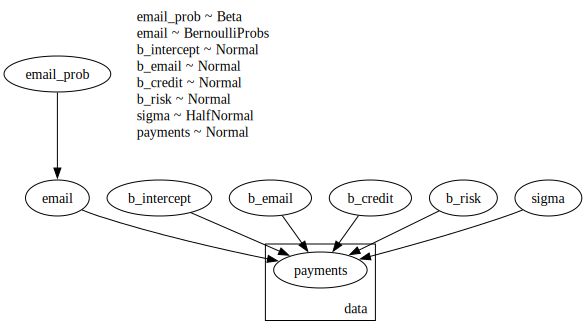

In [25]:
def email_causal_model(credit_limit, risk_score, email=None, payments=None):
    n_obs = credit_limit.shape[0]

    # Treatment model: email assignment (in this RCT it's random,
    # but we model it to enable do-calculus)
    email_prob = numpyro.sample("email_prob", dist.Beta(1.0, 1.0))
    email = numpyro.sample(
        "email", dist.Bernoulli(email_prob).expand([n_obs]).to_event(1), obs=email
    )

    # Outcome model: payments ~ email + credit_limit + risk_score
    b_intercept = numpyro.sample("b_intercept", dist.Normal(500.0, 100.0))
    b_email = numpyro.sample("b_email", dist.Normal(0.0, 10.0))
    b_credit = numpyro.sample("b_credit", dist.Normal(0.0, 10.0))
    b_risk = numpyro.sample("b_risk", dist.Normal(0.0, 10.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(10.0))

    mu = b_intercept + b_email * email + b_credit * credit_limit + b_risk * risk_score
    with numpyro.plate("data", n_obs):
        numpyro.sample("payments", dist.Normal(mu, sigma), obs=payments)


numpyro.render_model(
    email_causal_model,
    model_args=(credit_limit, risk_score),
    render_distributions=True,
)

In [26]:
# Fit the model with MCMC
kernel = NUTS(email_causal_model)
mcmc = MCMC(kernel, num_warmup=1_000, num_samples=1_000, num_chains=4)
mcmc.run(jax.random.key(0), credit_limit, risk_score, email=email, payments=payments)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
     b_credit      0.15      0.00      0.15      0.14      0.15   3909.11      1.00
      b_email      4.28      2.06      4.32      0.77      7.49   3562.58      1.00
  b_intercept    488.97      3.80    488.94    482.90    495.46   2869.60      1.00
       b_risk     -0.05      9.54      0.06    -16.63     14.78   2733.98      1.00
   email_prob      0.49      0.01      0.49      0.48      0.50   3784.22      1.00
        sigma     74.77      0.76     74.77     73.55     76.04   4074.74      1.00

Number of divergences: 0


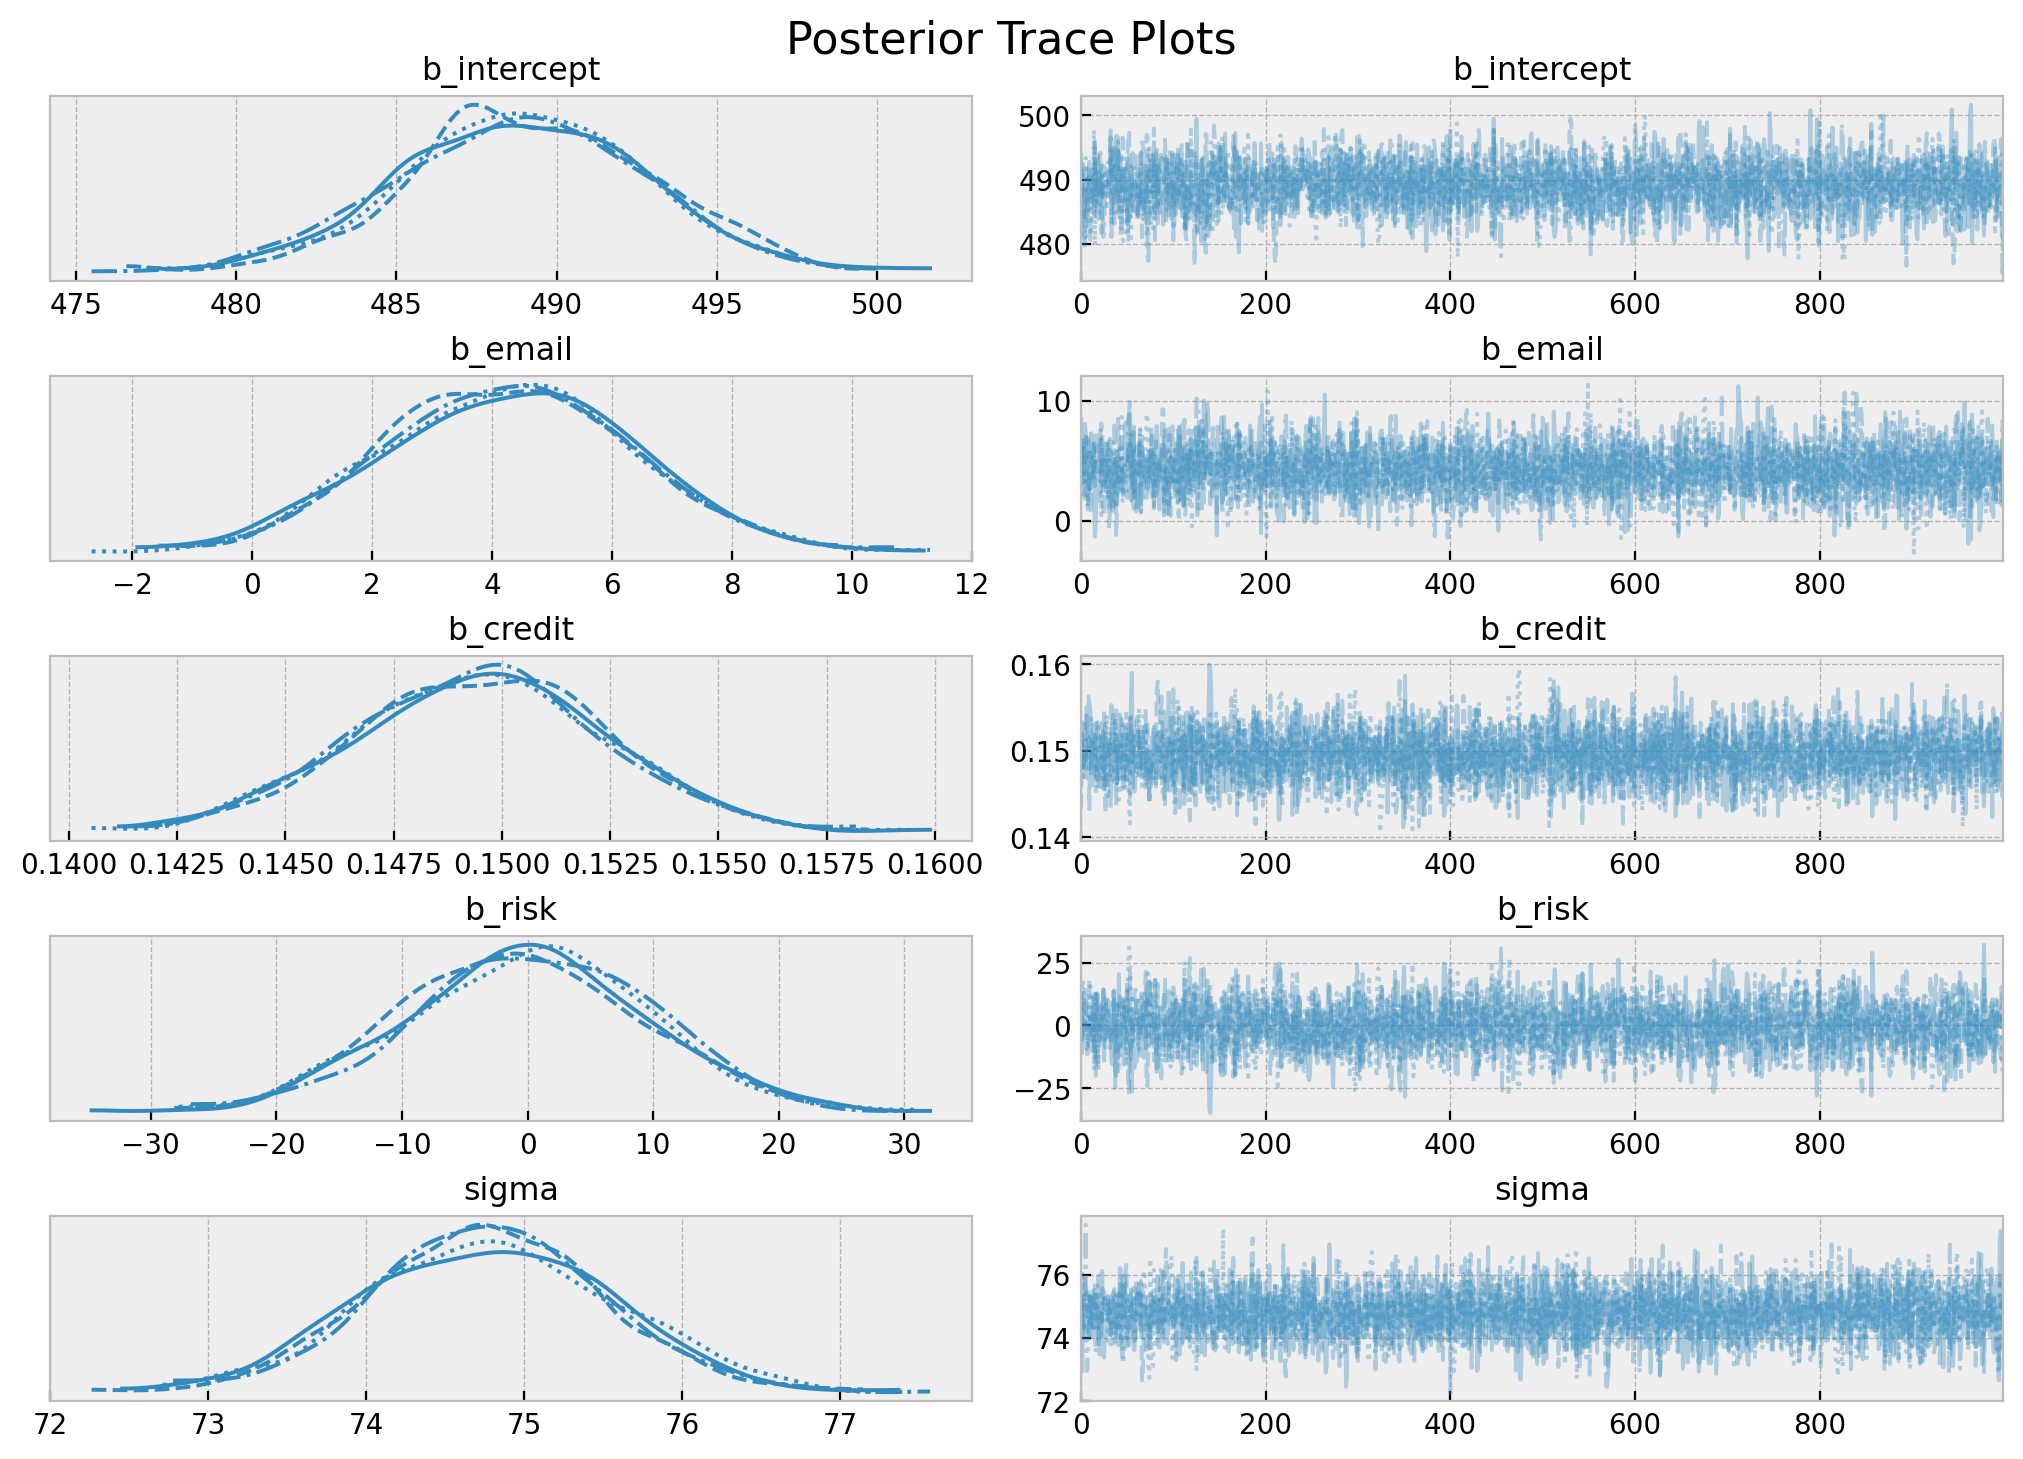

In [27]:
idata = az.from_numpyro(posterior=mcmc)

axes = az.plot_trace(
    data=idata,
    var_names=["b_intercept", "b_email", "b_credit", "b_risk", "sigma"],
    compact=True,
    backend_kwargs={"figsize": (10, 7), "layout": "constrained"},
)
plt.gcf().suptitle("Posterior Trace Plots", fontsize=16, y=1.02)
plt.show()

The `b_email` coefficient tells us the observational association.



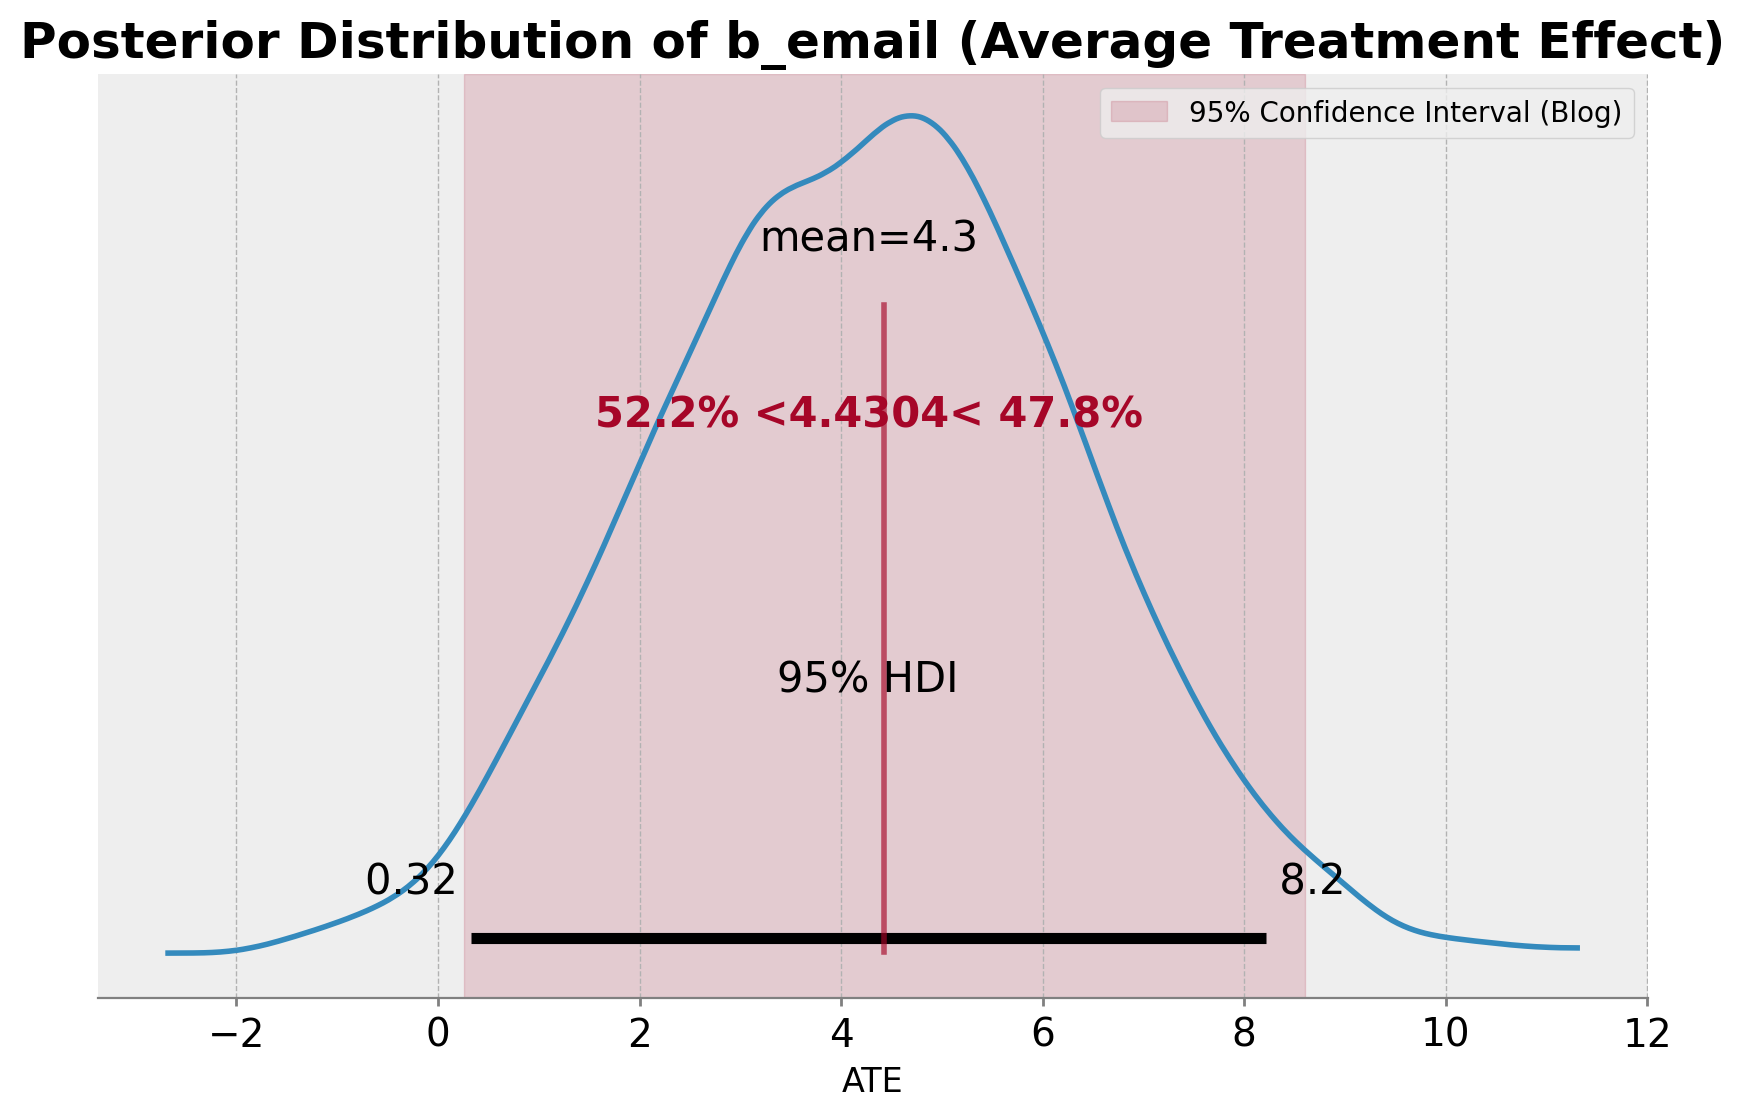

In [28]:
point_estimate_blog = 4.4304
ci_blog = (0.255, 8.606)

fig, ax = plt.subplots()
az.plot_posterior(
    idata,
    var_names=["b_email"],
    hdi_prob=0.95,
    ref_val=point_estimate_blog,
    ax=ax,
)
ax.axvspan(
    ci_blog[0],
    ci_blog[1],
    alpha=0.15,
    color="C1",
    label="95% Confidence Interval (Blog)",
)
ax.legend()
ax.set(xlabel="ATE")
ax.set_title(
    "Posterior Distribution of b_email (Average Treatment Effect)",
    fontsize=18,
    fontweight="bold",
);

Now let's use the `do` handler to compute the **interventional** average treatment effect (ATE).

In [ ]:
posterior_samples = mcmc.get_samples()

# do(email=1): everyone receives email
intervened_model_1 = handlers.do(
    email_causal_model, data={"email": jnp.ones_like(email)}
)
predictive_do_1 = Predictive(intervened_model_1, posterior_samples=posterior_samples)
rng_key, rng_subkey = jax.random.split(rng_key)
predictions_do_1 = az.from_dict(
    {
        k: v[jnp.newaxis, :]
        for k, v in predictive_do_1(rng_subkey, credit_limit, risk_score).items()
    },
    coords={"obs_idx": np.arange(len(email))},
    dims={"email": ["obs_idx"], "payments": ["obs_idx"]},
)

# do(email=0): no one receives email
intervened_model_0 = handlers.do(
    email_causal_model, data={"email": jnp.zeros_like(email)}
)
predictive_do_0 = Predictive(intervened_model_0, posterior_samples=posterior_samples)
predictions_do_0 = az.from_dict(
    {
        k: v[jnp.newaxis, :]
        for k, v in predictive_do_0(rng_subkey, credit_limit, risk_score).items()
    },
    coords={"obs_idx": np.arange(len(email))},
    dims={"email": ["obs_idx"], "payments": ["obs_idx"]},
)

# Compute ATE (average over individuals, keep posterior samples)
# Transform back to original scale
y_do_1 = predictions_do_1["posterior"]["payments"].mean(dim="obs_idx")
y_do_0 = predictions_do_0["posterior"]["payments"].mean(dim="obs_idx")
ate_posterior = (y_do_1 - y_do_0).rename("ate")

Let's compare the interventional ATE with the regression coefficient:

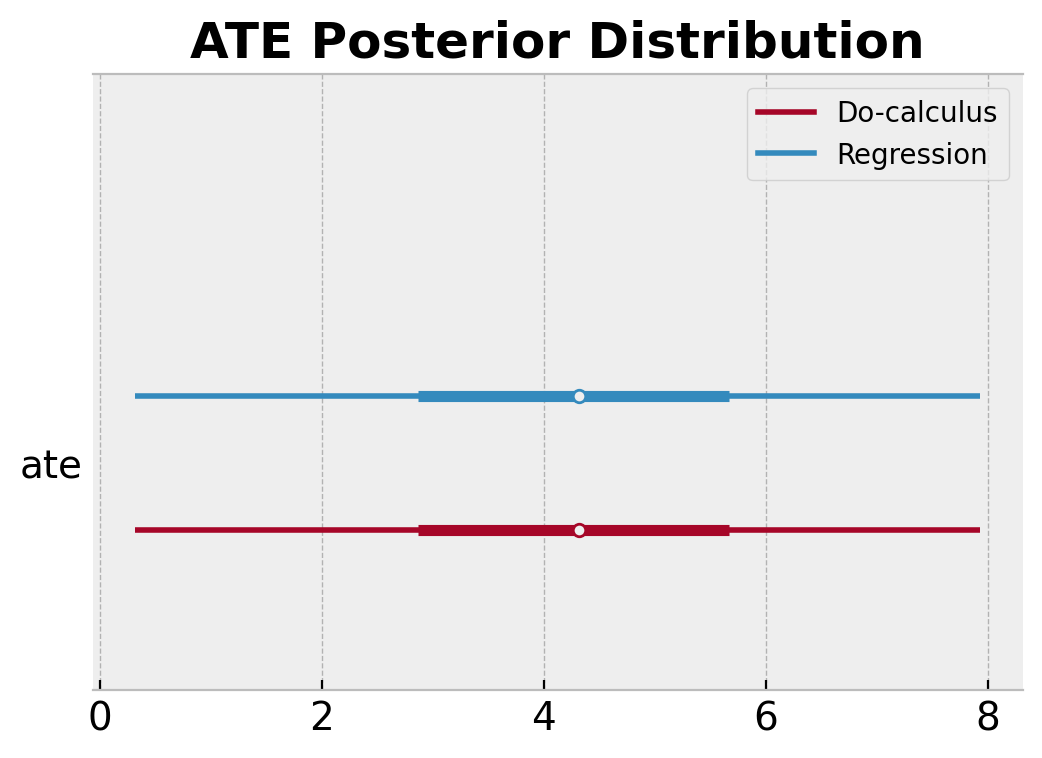

In [74]:
ax, *_ = az.plot_forest(
    [idata["posterior"]["b_email"].rename("ate"), ate_posterior],
    model_names=["Regression", "Do-calculus"],
    combined=True,
    figsize=(6, 4),
)
ax.set_title("ATE Posterior Distribution", fontsize=18, fontweight="bold");

Since `email` was randomly assigned in this experiment, the regression coefficient and the interventional ATE from do-calculus should be very similar: both estimating around $4$ units of additional payment. The `do` handler provides the machinery to do this in a principled way, which becomes essential when the treatment or the model are more complex.

## Reparameterization: `reparam`
<a id="reparameterization-reparam"></a>

The `reparam` handler transforms sample sites to improve posterior geometry. This is critical for hierarchical models that suffer from the "funnel" problem, where the posterior has regions of high curvature that make sampling difficult.

We demonstrate this with the classic **Eight Schools** example from Gelman et al., *Bayesian Data Analysis* (Sec. 5.5, 2003).

In [76]:
# Eight Schools data
J = 8
y_schools = jnp.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma_schools = jnp.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])


def eight_schools(J, sigma, y=None):
    mu = numpyro.sample("mu", dist.Normal(0, 5))
    tau = numpyro.sample("tau", dist.HalfCauchy(5))
    with numpyro.plate("J", J):
        theta = numpyro.sample("theta", dist.Normal(mu, tau))
        numpyro.sample("obs", dist.Normal(theta, sigma), obs=y)

### Centered Parameterization (with divergences)

The centered model `theta ~ Normal(mu, tau)` creates a "funnel": when `tau` is small, `theta` values must be tightly clustered around `mu`, creating a narrow region that NUTS struggles to navigate.

In [85]:
kernel_centered = NUTS(
    eight_schools,
    target_accept_prob=0.9,
)
mcmc_centered = MCMC(
    kernel_centered,
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
)
rng_key, rng_subkey = jax.random.split(rng_key)
mcmc_centered.run(rng_subkey, J, sigma_schools, y=y_schools)
mcmc_centered.print_summary(exclude_deterministic=False)

n_divergences_centered = mcmc_centered.get_extra_fields()["diverging"].sum()
print(f"\nNumber of divergences (centered): {n_divergences_centered}")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu      4.62      3.24      4.45     -0.67      9.95    447.98      1.00
       tau      3.56      2.91      2.74      0.37      7.29    244.45      1.01
  theta[0]      6.37      5.45      5.75     -2.06     14.16    641.28      1.00
  theta[1]      5.13      4.69      4.96     -2.21     13.13    861.44      1.00
  theta[2]      4.17      5.03      4.27     -4.01     11.86    878.15      1.00
  theta[3]      4.99      4.58      4.88     -1.91     12.98    717.99      1.00
  theta[4]      3.83      4.65      3.96     -3.63     11.37    844.18      1.00
  theta[5]      4.26      4.83      4.21     -3.29     12.13    762.41      1.00
  theta[6]      6.40      4.88      5.92     -1.17     14.31    555.85      1.00
  theta[7]      5.13      5.03      4.85     -3.20     12.90    932.50      1.00

Number of divergences: 76

Number of divergences (centered): 76


### Non-Centered Parameterization with `reparam`

The `LocScaleReparam(centered=0)` handler transforms `theta ~ Normal(mu, tau)` into `theta_decentered ~ Normal(0, 1)` and then computes `theta = mu + tau * theta_decentered`.
This eliminates the funnel geometry.

In [86]:
reparam_config = {"theta": LocScaleReparam(centered=0)}
reparam_eight_schools = handlers.reparam(eight_schools, config=reparam_config)

kernel_noncentered = NUTS(
    reparam_eight_schools,
    target_accept_prob=0.9,
)
mcmc_noncentered = MCMC(
    kernel_noncentered, num_warmup=1_000, num_samples=1_000, num_chains=4
)
rng_key, rng_subkey = jax.random.split(rng_key)
mcmc_noncentered.run(rng_subkey, J, sigma_schools, y=y_schools)
mcmc_noncentered.print_summary(exclude_deterministic=False)

n_divergences_noncentered = mcmc_noncentered.get_extra_fields()["diverging"].sum()
print(f"\nNumber of divergences (non-centered): {n_divergences_noncentered}")

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


                         mean       std    median      5.0%     95.0%     n_eff     r_hat
                 mu      4.35      3.28      4.38     -1.19      9.57   5054.49      1.00
                tau      3.64      3.21      2.77      0.00      7.91   3281.54      1.00
           theta[0]      6.09      5.57      5.51     -2.69     14.48   4397.13      1.00
           theta[1]      4.96      4.73      4.82     -2.92     12.39   5069.87      1.00
           theta[2]      3.82      5.33      4.08     -5.04     11.73   4363.34      1.00
           theta[3]      4.71      4.74      4.72     -3.36     11.94   5094.80      1.00
           theta[4]      3.66      4.69      3.88     -3.80     11.01   4233.14      1.00
           theta[5]      3.84      4.91      4.07     -3.59     11.93   4854.91      1.00
           theta[6]      6.26      5.06      5.81     -2.22     13.94   4465.73      1.00
           theta[7]      4.75      5.36      4.58     -3.52     13.22   4370.32      1.00
theta_dec

Let's inspect the trace to see the reparameterized sites:

In [87]:
reparam_trace = handlers.trace(
    handlers.seed(reparam_eight_schools, rng_seed=0)
).get_trace(J, sigma_schools)

print(f"{'Site':>20s} | {'Type':>15s} | {'Shape'}")
print("-" * 55)
for name, site in reparam_trace.items():
    print(f"{name:>20s} | {site['type']:>15s} | {jnp.shape(site['value'])}")

                Site |            Type | Shape
-------------------------------------------------------
                  mu |          sample | ()
                 tau |          sample | ()
                   J |           plate | (8,)
    theta_decentered |          sample | (8,)
               theta |   deterministic | (8,)
                 obs |          sample | (8,)


Notice that `theta_decentered` is a new sample site (sampling from `Normal(0, 1)`), while `theta` has become a deterministic site (computed as `mu + tau * theta_decentered`). This is the key insight: `reparam` changes the parameterization without changing the mathematical model.

## Composing Handlers: Nesting and Order
<a id="composing-handlers-nesting-and-order"></a>

The real power of effect handlers emerges when you compose them. Handlers are stacked via nesting, and **order matters** because `process_message` runs from the bottom of the stack (innermost handler) to the top (outermost handler). The outermost handler's `process_message` runs last, so it can overwrite values set by inner handlers.

```
with handlers.trace():           # TOP    — postprocess first, process last
    with handlers.condition():    # MIDDLE
        with handlers.seed():    # BOTTOM — process first, postprocess last
            model()
```

In [88]:
# condition then substitute on same site
trace1 = handlers.trace(
    handlers.condition(
        handlers.substitute(
            handlers.seed(linear_model, rng_seed=0), data={"slope": 10.0}
        ),
        data={"slope": 3.0},
    )
).get_trace(x_data)
print(
    f"condition(substitute(...)): slope={trace1['slope']['value']}, "
    f"is_observed={trace1['slope']['is_observed']}"
)

# substitute then condition on same site
trace2 = handlers.trace(
    handlers.substitute(
        handlers.condition(
            handlers.seed(linear_model, rng_seed=0), data={"slope": 3.0}
        ),
        data={"slope": 10.0},
    )
).get_trace(x_data)
print(
    f"substitute(condition(...)): slope={trace2['slope']['value']}, "
    f"is_observed={trace2['slope']['is_observed']}"
)

condition(substitute(...)): slope=3.0, is_observed=True
substitute(condition(...)): slope=10.0, is_observed=True


In the first case, `condition` (outer) runs its `process_message` **after** `substitute` (inner), so it overwrites the value to `3.0` and sets `is_observed=True`.

In the second case, `substitute` (outer) runs after `condition` (inner), so it overwrites the value to `10.0` — but `is_observed` was already set to `True` by `condition` and `substitute` does not change it.

In [89]:
# Equivalent using context managers
with handlers.trace() as tr:
    with handlers.condition(data={"slope": 2.5}):
        handlers.seed(linear_model, rng_seed=0)(x_data)

print(f"Context manager style: slope = {tr['slope']['value']}")

Context manager style: slope = 2.5


## Practical Recipe: Posterior Predictive with Handlers
<a id="practical-recipe-posterior-predictive-with-handlers"></a>

Let's tie everything together by using handlers to implement the full posterior
predictive workflow — the same operations that `Predictive` does internally.

In [91]:
# First, fit the linear model with MCMC
kernel = NUTS(conditioned_linear_model)
mcmc_linear = MCMC(
    kernel, num_warmup=1_000, num_samples=1_000, num_chains=4, progress_bar=False
)
rng_key, rng_subkey = jax.random.split(rng_key)
mcmc_linear.run(rng_subkey, x_data)
mcmc_linear.print_summary()
posterior_samples_linear = mcmc_linear.get_samples()


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  intercept      0.91      0.06      0.91      0.80      1.01   3839.09      1.00
      sigma      0.45      0.05      0.45      0.37      0.53   3375.28      1.00
      slope      2.01      0.05      2.01      1.92      2.10   4067.50      1.00

Number of divergences: 0


### Prior Predictive (using `seed` + `trace`)

To get a prior predictive sample, we simply trace the model without conditioning on any data:

In [92]:
prior_trace = handlers.trace(handlers.seed(linear_model, rng_seed=1)).get_trace(x_data)
y_prior = prior_trace["obs"]["value"]
print(f"Prior predictive sample shape: {y_prior.shape}")

Prior predictive sample shape: (50,)


### Posterior Predictive (using `substitute` + `seed` + `trace`)

To get a posterior predictive sample, we substitute one set of posterior samples and trace the model:

In [93]:
# Pick one posterior sample
one_sample = {k: v[0] for k, v in posterior_samples_linear.items()}
post_pred_trace = handlers.trace(
    handlers.seed(handlers.substitute(linear_model, data=one_sample), rng_seed=2)
).get_trace(x_data)
y_post = post_pred_trace["obs"]["value"]
print(f"Posterior predictive sample shape: {y_post.shape}")

Posterior predictive sample shape: (50,)


### Log-Likelihood (using `substitute` + `seed` + `trace`)

We can compose handlers to compute the pointwise log-likelihood:

In [ ]:
def log_likelihood(rng_key, params, model, *args, **kwargs):
    """Compute pointwise log-likelihood using handler composition."""
    model_sub = handlers.substitute(handlers.seed(model, rng_key), params)
    model_trace = handlers.trace(model_sub).get_trace(*args, **kwargs)
    obs_site = model_trace["obs"]
    return obs_site["fn"].log_prob(obs_site["value"])


rng_key, rng_subkey = jax.random.split(rng_key)
ll = log_likelihood(rng_subkey, one_sample, conditioned_linear_model, x_data)
print(f"Log-likelihood shape: {ll.shape}, sum: {ll.sum():.2f}")

Log-likelihood shape: (50,), sum: -30.71


### Comparison with `Predictive`

The `Predictive` utility does exactly this under the hood, composing `substitute`, `seed`, and `trace` handlers — but wraps it in a convenient `vmap` over all
posterior samples:

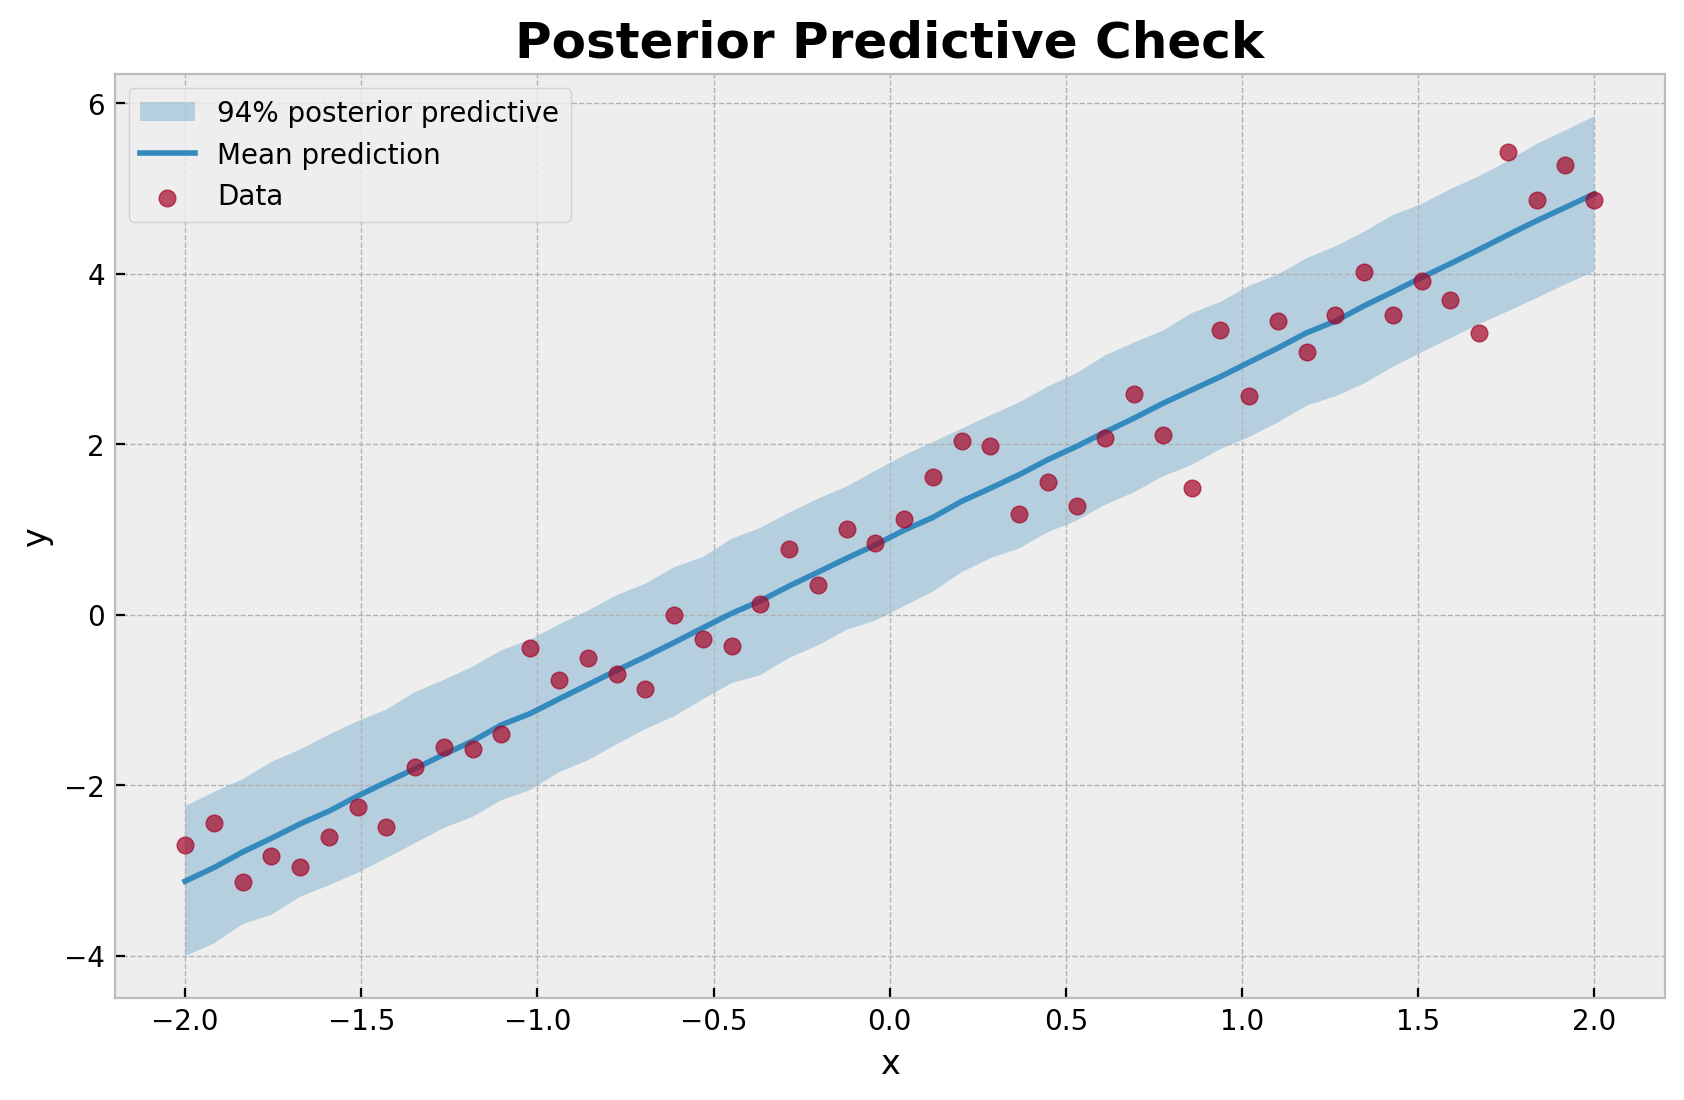

In [100]:
predictive = Predictive(linear_model, posterior_samples=posterior_samples_linear)
pred_samples = predictive(jax.random.key(4), x_data)

fig, ax = plt.subplots()
# Plot posterior predictive bands
y_pred = pred_samples["obs"]
ax.fill_between(
    x_data,
    *np.percentile(y_pred, [3, 97], axis=0),
    alpha=0.3,
    label="94% posterior predictive",
)
ax.plot(x_data, y_pred.mean(axis=0), label="Mean prediction")
ax.scatter(x_data, y_data, alpha=0.7, zorder=5, label="Data")
ax.legend()
ax.set(xlabel="x", ylabel="y", title="Posterior Predictive Check")
ax.set_title("Posterior Predictive Check", fontsize=18, fontweight="bold");

## Summary and References
<a id="summary-and-references"></a>

NumPyro provides 13+ composable effect handlers that let you manipulate
probabilistic programs without modifying model code. Here is a quick reference:

| Handler | What it does | Key `msg` fields |
|---------|-------------|-----------------|
| `seed` | Provides PRNG key splitting | `kwargs["rng_key"]` |
| `trace` | Records all sites into an `OrderedDict` | (reads all) |
| `condition` | Fixes value **and** marks as observed | `value`, `is_observed=True` |
| `substitute` | Fixes value, keeps observation status | `value` |
| `do` | Causal intervention (SWIG) | `name` (→ `__CF`), `value`, `is_observed` |
| `block` | Hides sites from outer handlers | `stop=True` |
| `uncondition` | Forces observed sites to sample from prior | `is_observed=False` |
| `lift` | Converts `param` → `sample` with a prior | `type` (→ `"sample"`) |
| `replay` | Replays values from a previous trace | `value` |
| `scope` | Prepends prefix to site names | `name` |
| `scale` | Multiplies log-prob scaling factor | `scale` |
| `mask` | Element-wise boolean masking of log-prob | `fn` (→ `MaskedDistribution`) |
| `reparam` | Reparameterizes sample sites | `fn`, `value`, `name` |

### References

- [Mini Pyro](https://pyro.ai/examples/minipyro.html) — the foundational tutorial
  on effect handlers in the Pyro ecosystem
- [Pyro Effect Handlers](http://pyro.ai/examples/effect_handlers.html) — Pyro's
  perspective on the handler pattern
- [NumPyro Handlers API](https://numpyro.readthedocs.io/en/latest/handlers.html) —
  official API documentation
- [Causal Inference for the Brave and True, Ch.7](https://matheusfacure.github.io/python-causality-handbook/07-Beyond-Confounders.html) —
  the collections email example
- [Single World Intervention Graphs](https://arxiv.org/abs/1201.0816) —
  Richardson & Robins, the theory behind the `do` handler
- Gelman et al., *Bayesian Data Analysis* (Sec. 5.5, 2003) — the Eight Schools
  example